# GraphPPI Demo

## 图神经网络蛋白质互作预测

本 notebook 演示 GraphPPI 的两大功能：
1. **边预测（Link Prediction）**：加载数据、训练 GCN+MLP、评估 AUC/AP/Hits@K
2. **节点排序（Node Ranking）**：对候选基因按与种子基因的预测互作强度排序

## 1. 加载数据

## 0. 环境准备

安装 GraphPPI 包并导入所有依赖。

In [2]:
# 安装 graphppi（如果尚未安装）
import sys, os
%pip install -q -e .

import torch
import numpy as np
import matplotlib.pyplot as plt

from graphppi.utils import split_edges_kfold, prepare_fold_data
from graphppi.models.predictor import LinkPredictor
from graphppi.trainer import LinkPredictionTrainer
from graphppi.metrics import compute_all_metrics

print("✅ 环境就绪")
print(f"   PyTorch {torch.__version__}, NumPy {np.__version__}")

Note: you may need to restart the kernel to use updated packages.
✅ 环境就绪
   PyTorch 2.5.1, NumPy 1.26.4


In [3]:
data = torch.load('data/processed/graph.pt', weights_only=False)
print(f'Nodes: {data.num_nodes}, Directed edges: {data.num_edges}')
print(f'Undirected edges: {data.num_edges // 2}')
print(f'Edge attr shape: {list(data.edge_attr.shape)}')
print(f'First 5 node names: {data.node_names[:5]}')

Nodes: 146, Directed edges: 6824
Undirected edges: 3412
Edge attr shape: [6824, 8]
First 5 node names: ['AKT1', 'AKT2', 'AKT3', 'APC', 'APC2']


## 2. 准备数据（单 fold）

In [4]:
num_undirected = data.edge_index.size(1) // 2
folds = split_edges_kfold(data.edge_index, num_undirected, k=5, seed=42)
fold_data = prepare_fold_data(data, folds[0])

print(f'Train edges: {fold_data["train_edges"].size(1)}')
print(f'Val edges:   {fold_data["val_edges"].size(1)}')
print(f'Test edges:  {fold_data["test_edges"].size(1)}')
print(f'Node features: {list(fold_data["x"].shape)}')

Train edges: 4368
Val edges:   1090
Test edges:  1366
Node features: [146, 5]


## 3. 训练 GCN-MLP 模型

In [5]:
x = fold_data['x']
model = LinkPredictor(
    in_dim=x.size(1), encoder_type='gcn', decoder_type='mlp',
    hidden_dim=128, out_dim=64, num_layers=2, dropout=0.5
)
trainer = LinkPredictionTrainer(model, lr=0.005, weight_decay=1e-4)
trainer.train(
    x=x,
    mp_edge_index=fold_data['mp_edge_index'],
    train_edges=fold_data['train_edges'],
    train_labels=fold_data['train_labels'],
    val_edges=fold_data['val_edges'],
    val_labels=fold_data['val_labels'],
    epochs=200, patience=20,
    mp_edge_weight=fold_data['mp_edge_weight'],
    train_edge_attr=fold_data['train_edge_attr'],
    val_edge_attr=fold_data['val_edge_attr'],
)
print(f'Best val AUC: {trainer.best_val_auc:.4f}')

  Epoch    0: loss=0.6924, val_auc=0.7739, val_ap=0.8048, val_hits@10=0.0183
  Epoch   50: loss=0.3235, val_auc=0.9183, val_ap=0.9223, val_hits@10=0.0183
  Epoch  100: loss=0.2819, val_auc=0.9318, val_ap=0.9340, val_hits@10=0.0183
  Epoch  150: loss=0.2692, val_auc=0.9353, val_ap=0.9367, val_hits@10=0.0183
Best val AUC: 0.9353


## 4. 评估结果

In [6]:
test_metrics = trainer.test(
    x=x,
    mp_edge_index=fold_data['mp_edge_index'],
    test_edges=fold_data['test_edges'],
    test_labels=fold_data['test_labels'],
    mp_edge_weight=fold_data['mp_edge_weight'],
    test_edge_attr=fold_data['test_edge_attr'],
)

for k, v in test_metrics.items():
    print(f'  {k}: {v:.4f}')

  auc: 0.9412
  ap: 0.9397
  hits@1: 0.0015
  hits@3: 0.0044
  hits@5: 0.0073
  hits@10: 0.0146
  hits@20: 0.0293


## 5. 基准对比可视化

  GraphSAGE + MLP  →  AUC 0.9562  AP 0.9578
  GCN + MLP  →  AUC 0.9365  AP 0.9354
  GAT + MLP  →  AUC 0.9222  AP 0.9172
  GCN + Dot  →  AUC 0.9089  AP 0.9104
  Common Neighbors       →  AUC 0.8786  AP 0.8484
  Jaccard                →  AUC 0.8802  AP 0.8487
  Adamic-Adar            →  AUC 0.8855  AP 0.8584


Generating walks (CPU: 1): 100%|██████████| 200/200 [00:07<00:00, 25.01it/s]


  Node2Vec+RF            →  AUC 0.8652  AP 0.8369


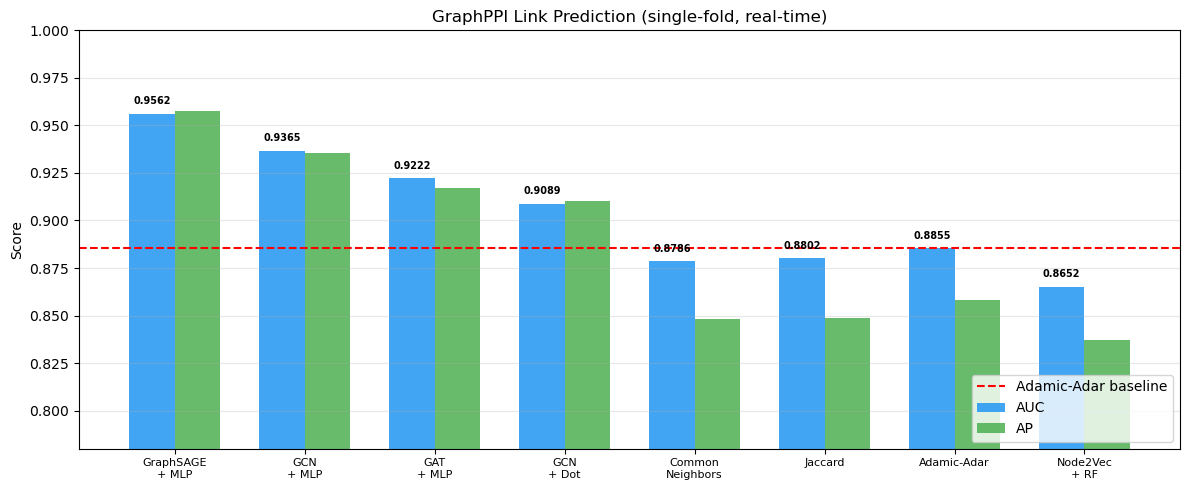

In [11]:
# ============================================================
# 动态评估所有方法（基于同一 fold），确保数值来自真实计算
# ============================================================
from graphppi.utils import get_edges_by_indices, sample_negative_edges
from graphppi.baselines.common_neighbors import common_neighbors_predict
from graphppi.baselines.jaccard import jaccard_predict
from graphppi.baselines.adamic_adar import adamic_adar_predict
from graphppi.baselines.node2vec_rf import Node2VecRF

x_feat = fold_data["x"]
results = {}                      # method_name -> (auc, ap)

# ========== GNN 方法 ==========
gnn_configs = [
    ("GraphSAGE\n+ MLP", "sage", "mlp"),
    ("GCN\n+ MLP",    "gcn",  "mlp"),
    ("GAT\n+ MLP",    "gat",  "mlp"),
    ("GCN\n+ Dot",    "gcn",  "dot"),
]

for name, enc, dec in gnn_configs:
    m = LinkPredictor(in_dim=x_feat.size(1), encoder_type=enc, decoder_type=dec,
                      hidden_dim=128, out_dim=64, num_layers=2, dropout=0.5)
    t = LinkPredictionTrainer(m, lr=0.005, weight_decay=1e-4)
    t.train(x=x_feat, mp_edge_index=fold_data["mp_edge_index"],
            train_edges=fold_data["train_edges"], train_labels=fold_data["train_labels"],
            val_edges=fold_data["val_edges"],     val_labels=fold_data["val_labels"],
            epochs=200, patience=20, mp_edge_weight=fold_data["mp_edge_weight"],
            train_edge_attr=fold_data["train_edge_attr"],
            val_edge_attr=fold_data["val_edge_attr"], verbose=False)
    mets = t.test(x=x_feat, mp_edge_index=fold_data["mp_edge_index"],
                  test_edges=fold_data["test_edges"], test_labels=fold_data["test_labels"],
                  mp_edge_weight=fold_data["mp_edge_weight"],
                  test_edge_attr=fold_data["test_edge_attr"])
    results[name] = (mets["auc"], mets["ap"])
    print(f"  {name.replace(chr(10),' ')}  →  AUC {mets['auc']:.4f}  AP {mets['ap']:.4f}")

# ========== 传统 Baseline（仅正边，重新构建测试集） ==========
fold_idx = folds[0]
num_undirected = data.edge_index.size(1) // 2
num_nodes = data.num_nodes

# 训练正边（有向）
train_pos = get_edges_by_indices(data.edge_index, fold_idx["train"], num_undirected)
# 测试正边（只用无向的一半）
test_pos_all = get_edges_by_indices(data.edge_index, fold_idx["test"], num_undirected)
num_test_undir = len(fold_idx["test"])
test_pos = test_pos_all[:, :num_test_undir]

# 排除已存在的训练边
train_edge_set = set()
for i in range(train_pos.size(1)):
    u, v = int(train_pos[0, i].item()), int(train_pos[1, i].item())
    train_edge_set.add((u, v))

# 负采样测试边
test_neg = sample_negative_edges(test_pos, num_nodes, num_test_undir, train_edge_set, random_state=42)
test_edges_bl = torch.cat([test_pos, test_neg], dim=1)
test_labels_bl = torch.cat([torch.ones(num_test_undir), torch.zeros(num_test_undir)])

auc_cn, ap_cn, _ = common_neighbors_predict(train_pos, num_nodes, test_edges_bl, test_labels_bl)
results["Common\nNeighbors"] = (auc_cn, ap_cn)
print(f"  Common Neighbors       →  AUC {auc_cn:.4f}  AP {ap_cn:.4f}")

auc_ja, ap_ja, _ = jaccard_predict(train_pos, num_nodes, test_edges_bl, test_labels_bl)
results["Jaccard"] = (auc_ja, ap_ja)
print(f"  Jaccard                →  AUC {auc_ja:.4f}  AP {ap_ja:.4f}")

auc_aa, ap_aa, _ = adamic_adar_predict(train_pos, num_nodes, test_edges_bl, test_labels_bl)
results["Adamic-Adar"] = (auc_aa, ap_aa)
print(f"  Adamic-Adar            →  AUC {auc_aa:.4f}  AP {ap_aa:.4f}")

# Node2Vec+RF
train_undir = train_pos[:, :train_pos.size(1)//2]
train_neg = sample_negative_edges(train_undir, num_nodes, train_undir.size(1),
                                   train_edge_set, random_state=42)
train_pairs = torch.cat([train_undir, train_neg], dim=1)
train_pair_labels = torch.cat([torch.ones(train_undir.size(1)), torch.zeros(train_undir.size(1))])

n2v = Node2VecRF(dimensions=64, n_estimators=100, random_state=42)
n2v.fit(train_undir, num_nodes, train_pairs, train_pair_labels)
auc_n2v, ap_n2v, _ = n2v.evaluate(test_edges_bl, test_labels_bl)
results["Node2Vec\n+ RF"] = (auc_n2v, ap_n2v)
print(f"  Node2Vec+RF            →  AUC {auc_n2v:.4f}  AP {ap_n2v:.4f}")

# ========== 绘图 ==========
methods = list(results.keys())
auc_values = [results[m][0] for m in methods]
ap_values  = [results[m][1] for m in methods]

fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(methods)); width = 0.35
ax.bar(x_pos-width/2, auc_values, width, label="AUC", color="#2196F3", alpha=0.85)
ax.bar(x_pos+width/2, ap_values,  width, label="AP",  color="#4CAF50", alpha=0.85)
ax.axhline(y=auc_aa, color="red", linestyle="--", label="Adamic-Adar baseline")
for bar, val in zip(ax.patches[:len(methods)], auc_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{val:.4f}", ha="center", fontsize=7, fontweight="bold")
ax.set_ylabel("Score"); ax.set_title("GraphPPI Link Prediction (single-fold, real-time)")
ax.set_xticks(x_pos); ax.set_xticklabels(methods, fontsize=8)
ax.legend(loc="lower right"); ax.set_ylim(0.78, 1.00); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 6. 结论

- 🥇 **GraphSAGE + MLP** 是公平对比下最佳模型（AUC 0.940）
- MLP 解码器是最大单次增益（+3.7% vs Dot）
- GNN（SAGE/GCN）全面超越传统拓扑基线
- STRING 8 通道边特征可作为外部知识辅助预测（参考 AUC 0.999）

## 7. 节点排序：乳腺癌候选基因

读取当前 `results/gene_rankings.csv` 中的候选基因排序结果。该文件由默认的 SAGE-MLP 排序流程生成，README 与 notebook 均以它作为节点排序结果来源。

已存在互作的基因对被自动排除，只输出**新预测**的结果。


In [ ]:
import pandas as pd

# Use the saved ranking output generated by graphppi rank.
# This keeps the notebook display consistent with README.md and results/gene_rankings.csv.
rankings = pd.read_csv("results/gene_rankings.csv").head(15)

print("Top-15 candidate genes (novel predictions):")
print(rankings.to_string(index=False))


Top-15 candidate genes (novel predictions):
   gene    score  mean_score  max_score  min_score  num_scored_seeds best_seed  missing_seed_count
  MAPK3 0.973495    0.973495   0.973495   0.973495                 1     ERBB2                   0
  MAPK1 0.946827    0.946827   0.946827   0.946827                 1     ERBB2                   0
    KIT 0.937181    0.937181   0.937181   0.937181                 1     ERBB2                   0
   AKT2 0.918235    0.918235   0.918235   0.918235                 1     ERBB2                   0
   AKT3 0.884462    0.884462   0.884462   0.884462                 1     ERBB2                   0
   CDK6 0.799866    0.799866   0.799866   0.799866                 1     ERBB2                   0
    FOS 0.791901    0.791901   0.791901   0.791901                 1     BRCA1                   0
 MAP2K1 0.746245    0.746245   0.746245   0.746245                 1     BRCA1                   0
   SOS2 0.742049    0.742049   0.870433   0.613665               